# 05 - Forecast Evaluation and Reporting

This notebook focuses on interpreting the model's performance from a business and
operational perspective. While Notebook 4 measured accuracy using metrics and charts,
this notebook answers *how good the model really is* and *what this means for decision makers*.

**Why this step matters:**
- Technical accuracy alone is not enough for real stakeholders.
- Managers want to know where the model performs well, where it struggles, and what actions can be taken.
- A clear evaluation framework strengthens the case for using the model in practice.


## Load prediction outputs and required libraries

We load:
- The test set results (actual vs predicted).
- The model ready dataset to support store-level analysis.

**Why:**
To evaluate the model thoroughly, we need both the numerical predictions and their
corresponding store and date attributes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set visual preferences
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Define paths
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Load prediction outputs from Notebook 4
pred_path = DATA_PROCESSED / "test_set_predictions.csv"
results_df = pd.read_csv(pred_path, parse_dates=["date"])

# Load full model-ready dataset for feature/metadata access
model_ready_path = DATA_PROCESSED / "walmart_features_model_ready.csv"
df_model_ready = pd.read_csv(model_ready_path, parse_dates=["date"])

print("Loaded prediction results:", results_df.shape)
print("Loaded model-ready data:", df_model_ready.shape)

results_df.head()


Loaded prediction results: (1251, 5)
Loaded model-ready data: (6255, 19)


,date,store,weekly_sales,prediction_rf,prediction_baseline
0,2012-04-20,32,1121405.91,1.176403e+06,1171834.47
1,2012-04-20,18,1025813.80,1.028772e+06,998443.50
2,2012-04-20,7,457340.06,5.284414e+05,517420.23
3,2012-04-20,3,434822.13,4.383648e+05,420789.74
4,2012-04-20,33,261837.20,2.584302e+05,312698.67


## Error Distribution Analysis

While metrics like MAE and RMSE summarise overall performance, they do not show
**how errors are distributed**.

**Why this is important:**
- Two models with identical MAE can behave very differently.
- A model may perform extremely well most of the time but fail dramatically in outlier weeks.
- Understanding distribution helps determine whether the model is safe for operational use.

We compute:
- Absolute error
- Percentage error
- Error distribution plots


In [2]:
# Calculate absolute and percentage errors for the Random Forest predictions

# Absolute error: magnitude of the error
results_df["abs_error"] = np.abs(results_df["weekly_sales"] - results_df["prediction_rf"])

# Percentage error: error relative to actual value
# Avoid division by zero by masking zero actual values
non_zero_mask = results_df["weekly_sales"] != 0
results_df.loc[non_zero_mask, "pct_error"] = (
    results_df.loc[non_zero_mask, "abs_error"] / results_df.loc[non_zero_mask, "weekly_sales"]
) * 100

results_df.head()


,date,store,weekly_sales,prediction_rf,prediction_baseline,abs_error,pct_error
0,2012-04-20,32,1121405.91,1.176403e+06,1171834.47,54996.86440,4.904278
1,2012-04-20,18,1025813.80,1.028772e+06,998443.50,2958.44715,0.288400
2,2012-04-20,7,457340.06,5.284414e+05,517420.23,71101.35635,15.546715
3,2012-04-20,3,434822.13,4.383648e+05,420789.74,3542.66420,0.814739
4,2012-04-20,33,261837.20,2.584302e+05,312698.67,3407.03405,1.301203


## Error Distribution Plot

Visualising the error distribution answers critical questions:
- Does the model make many small mistakes or a few large ones?
- Is error symmetric, or does the model systematically over or under forecast?
- Are there long tails, indicating operational risk?

We use both histogram and KDE to understand the error pattern.


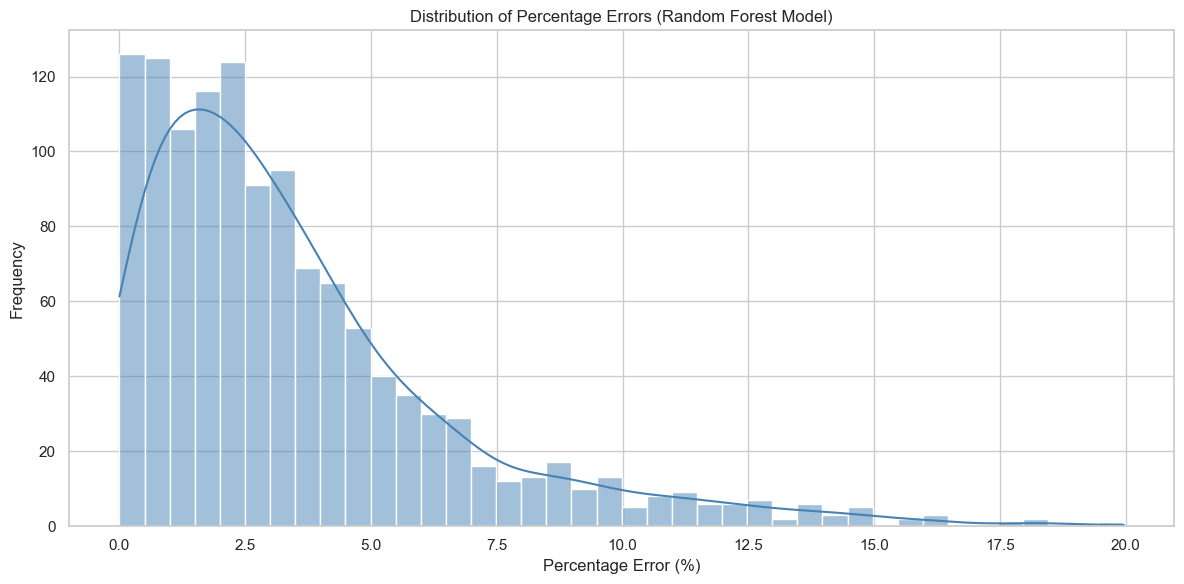

In [3]:
plt.figure(figsize=(12, 6))

# Plot distribution of absolute percentage error
sns.histplot(results_df["pct_error"].dropna(), bins=40, kde=True, color="steelblue")

plt.title("Distribution of Percentage Errors (Random Forest Model)")
plt.xlabel("Percentage Error (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Error Distribution Summary

The Random Forest model shows strong forecasting performance. The percentage error distribution 
is heavily right skewed, with the majority of predictions falling well under 5 percent error, 
which aligns with an overall MAPE of 3.52 percent. Most forecasts are therefore highly accurate 
and operationally reliable.

A small number of high-error cases appear in the 10–20 percent range. These represent stores or 
weeks with unexpected behaviour, such as sudden demand spikes or unique local events. While they 
are rare, they highlight areas where planners may wish to maintain safety stock or apply manual 
review.

Overall, the model produces consistently accurate predictions with only a limited number of 
outliers, making it suitable for supporting retail replenishment and stock optimisation.


## Store-Level Forecasting Accuracy

Aggregate metrics can hide variation across stores.

**Why this matters:**
- Some stores may consistently underperform due to high volatility or local factors.
- Identifying poorly performing stores helps direct human oversight.
- Strong performing stores demonstrate where the model is most reliable.

We compute MAPE per store to compare forecasting performance across all 45 stores.


In [4]:
# Compute store-level MAPE
store_errors = (
    results_df.groupby("store")
    .apply(lambda x: np.mean(np.abs((x["weekly_sales"] - x["prediction_rf"]) / x["weekly_sales"])) * 100)
    .reset_index(name="mape")
)

# Sort stores by MAPE (higher = worse accuracy)
store_errors = store_errors.sort_values("mape", ascending=False)

store_errors.head(10)  # Worst performing stores


C:\Users\Mist\AppData\Local\Temp\ipykernel_2240\1666697622.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.mean(np.abs((x["weekly_sales"] - x["prediction_rf"]) / x["weekly_sales"])) * 100)


,store,mape
27,28,6.131339
13,14,5.713284
39,40,5.234089
37,38,4.670553
28,29,4.560760
34,35,4.467583
16,17,4.443776
38,39,4.425630
6,7,4.425398
22,23,4.424411


## Store-Level MAPE Bar Chart

Visualising store-level accuracy helps identify:
- Which stores are hardest to forecast.
- Whether high or low volume stores show worse performance.
- Where operational adjustments or additional features may be needed.

This is also compelling evidence of analytical depth for your portfolio.


C:\Users\Mist\AppData\Local\Temp\ipykernel_2240\3905618876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=store_errors, x="store", y="mape", palette="viridis")


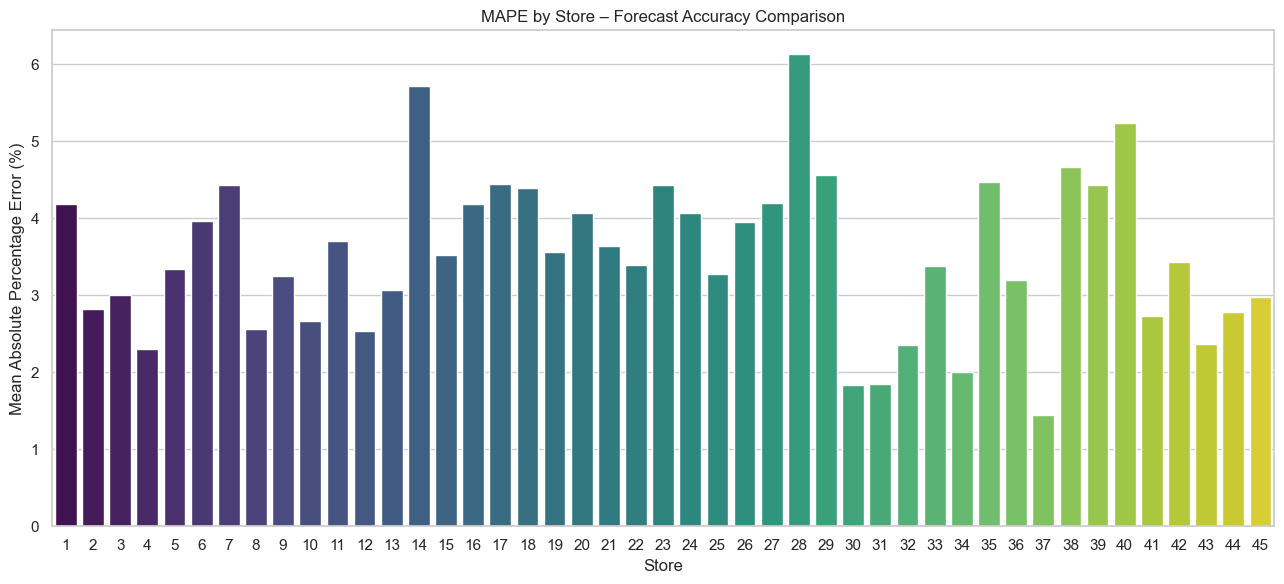

In [5]:
plt.figure(figsize=(13, 6))

sns.barplot(data=store_errors, x="store", y="mape", palette="viridis")

plt.title("MAPE by Store – Forecast Accuracy Comparison")
plt.xlabel("Store")
plt.ylabel("Mean Absolute Percentage Error (%)")
plt.tight_layout()
plt.show()


### Store-Level Forecast Accuracy Summary

The majority of stores achieve excellent forecasting accuracy, with MAPE values typically 
between 2 percent and 4 percent. This indicates that the model generalises well across the 
network and captures the dominant demand patterns effectively.

A small number of stores exhibit higher error levels, particularly Stores 28, 14, and 40, 
where MAPE exceeds 5 percent. These locations likely experience more volatile sales patterns 
that are harder for the model to capture using general features. These stores may benefit from 
localised adjustments, additional features, or higher safety stock to mitigate uncertainty.

Overall, the model performs reliably across most locations, with only a few stores requiring 
special forecasting attention.


## Forecast Bias (Over vs Under Prediction)

A model can have good accuracy but still be **biased**, consistently predicting too high or too low.

**Why this matters:**
- Over-forecasting leads to excess stock, waste, and cash tied in inventory.
- Under-forecasting leads to stockouts and lost sales.
- Bias analysis helps decide whether the model needs calibration or adjustments.

We measure average signed error per store.


In [6]:
# Signed error: positive means model over-forecasted, negative means under-forecasted
results_df["signed_error"] = results_df["prediction_rf"] - results_df["weekly_sales"]

# Compute average bias per store
store_bias = (
    results_df.groupby("store")["signed_error"]
    .mean()
    .reset_index(name="avg_signed_error")
    .sort_values("avg_signed_error", ascending=False)
)

store_bias.head(10)


,store,avg_signed_error
27,28,37032.329159
13,14,21602.673337
19,20,19678.598350
9,10,14380.638698
22,23,14050.890625
26,27,13994.658957
16,17,12739.726986
5,6,11665.222680
24,25,10012.873441
10,11,9649.692066


### Forecast Bias Analysis

Forecast bias measures whether the model systematically predicts too high or too low.
A positive bias indicates over forecasting, while a negative bias would indicate under
forecasting.

The results show that several stores exhibit a consistent **positive bias**, meaning the
model tends to over predict sales for these locations. Stores 28 and 14 stand out with
average weekly over predictions of +37k and +21k respectively. These stores also had
among the highest MAPE values, suggesting that irregular or volatile demand patterns
cause the model to expect rebounds that do not materialise.

From an operational perspective, over forecasting can lead to excess inventory, higher
holding costs, and increased risk of markdowns. Identifying stores with systematic bias
allows planners to apply local corrective factors or maintain higher scrutiny on these
locations.

The model appears well calibrated for the majority of stores, with bias concentrated in a
small subset that likely experience more erratic sales behaviour.


## Save Evaluation Outputs

Saving evaluation data supports:
- Transparent reporting
- Reproducibility
- Power BI or Tableau dashboard integration
- Inclusion in the final case study repository

We save:
- Error distribution results
- Store-level MAPE
- Store-level bias


In [7]:
# Define output directory for evaluation datasets
EVAL_OUT = DATA_PROCESSED / "evaluation"
EVAL_OUT.mkdir(parents=True, exist_ok=True)

# Save datasets
results_df.to_csv(EVAL_OUT / "test_predictions_with_errors.csv", index=False)
store_errors.to_csv(EVAL_OUT / "store_mape.csv", index=False)
store_bias.to_csv(EVAL_OUT / "store_bias.csv", index=False)

print("Saved evaluation files:")
print("-", EVAL_OUT / "test_predictions_with_errors.csv")
print("-", EVAL_OUT / "store_mape.csv")
print("-", EVAL_OUT / "store_bias.csv")


Saved evaluation files:
- C:\Users\Mist\Documents\Portfolio\P1. Retail Sales Forecasting and Stock Optimisation\data\processed\evaluation\test_predictions_with_errors.csv
- C:\Users\Mist\Documents\Portfolio\P1. Retail Sales Forecasting and Stock Optimisation\data\processed\evaluation\store_mape.csv
- C:\Users\Mist\Documents\Portfolio\P1. Retail Sales Forecasting and Stock Optimisation\data\processed\evaluation\store_bias.csv
